# Self-Consistency Experiments: Multi-Model Analysis

This notebook runs self-consistency analysis on the validated test set for **multiple models**.

**Self-consistency** measures how reliably an LLM produces the same answer when given identical inputs at `temperature=1.0`.

## Key Insight
Self-consistency is the **foundation** for model comparison. To meaningfully compare models, you must first understand each model's inherent stochasticity:
- If gpt-5 has 95% self-consistency and 42% agreement with gpt-oss-120b → **systematic difference**
- If gpt-5 has 50% self-consistency and 42% agreement with gpt-oss-120b → **inherent task ambiguity**

## Workflow
1. **Export** - Download LLM calls from production (with render_context)
2. **Sample** - Randomly sample N cases per call type
3. **Run** - Execute N self-consistency runs per call type **for each model**
4. **Analyze** - Calculate Fleiss' kappa and consistency metrics per model
5. **Compare** - Cross-model agreement analysis (in separate notebook)

## 1. Setup & Configuration

In [1]:
import json
import random
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# EXPERIMENT CONFIGURATION
# ============================================================================

# Test set configuration
TEST_SET_TAG = 'test_set_2025_11_26'
SAMPLE_SIZE = 100
RANDOM_SEED = 42
TEMPERATURE = 1.0

# Number of runs per model (configurable)
# 3 runs = faster/cheaper, minimum for Fleiss kappa
# 5 runs = more statistical power, better for publication
NUM_RUNS = 5

# Models to run self-consistency experiments for
# Run for ALL models you want to compare
MODELS = [
    'openai/gpt-5',
    'bedrock/openai.gpt-oss-120b-1:0',
]

# Helper function for model directory naming
def model_slug(model_name):
    """Convert model name to safe directory slug."""
    return model_name.replace('/', '_').replace(':', '_').replace('.', '_')

# Single source of truth: call type -> prompt path + handler class
# This is THE configuration for self-consistency experiments
CALL_TYPE_CONFIG = {
    'instrument_validation': {
        'prompt': 'paper_data_linking/linkers/general/prompts/validation/system.xml',
        'handler': 'InstrumentValidationHandler',
    },
    'wavelength_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/wavelength_normalization/system.xml',
        'handler': 'WavelengthNormalizationSimpleHandler',
    },
    'physobs_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/physobs_normalization/system.xml',
        'handler': 'PhysObsNormalizationFreeTextV2Handler',
    },
    'mission_selection': {
        'prompt': 'paper_data_linking/linkers/general/prompts/mission_selection/system.xml',
        'handler': 'MissionSelectionHandler',
    },
    'instrument_selection': {
        'prompt': 'paper_data_linking/linkers/general/prompts/instrument_selection/system.xml',
        'handler': 'InstrumentSelectionHandler',
    },
    'detector_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/detector_normalization/system.xml',
        'handler': 'DetectorNormalizationFreeTextV2Handler',
    },
    'time_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/time_normalization/system.xml',
        'handler': 'TimeNormalizationHandler',
    },
    'cadence_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/cadence_normalization/system.xml',
        'handler': 'CadenceNormalizationFreeTextHandler',
    },
    'mission_identification': {
        'prompt': 'paper_data_linking/linkers/general/prompts/mission_identification/system.xml',
        'handler': 'MissionIdentificationHandler',
    },
}

# Derived lists for convenience
CALL_TYPES = list(CALL_TYPE_CONFIG.keys())
HANDLER_MAP = {ct: cfg['handler'] for ct, cfg in CALL_TYPE_CONFIG.items()}

# Paths (relative to notebook location: experiments/compare_models/self_consistency/)
INPUT_DIR = Path('../../../inputs/test_set')  # -> inputs/test_set/ at repo root
RESULTS_DIR = Path('results')  # -> experiments/compare_models/self_consistency/results/

print(f"Test Set: {TEST_SET_TAG}")
print(f"Sample Size: {SAMPLE_SIZE}")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Num Runs: {NUM_RUNS}")
print(f"Models: {len(MODELS)}")
for m in MODELS:
    print(f"  - {m} ({model_slug(m)})")
print(f"Call Types: {len(CALL_TYPES)}")
print(f"\nTotal experiments needed: {len(MODELS)} models × {len(CALL_TYPES)} call types × {NUM_RUNS} runs = {len(MODELS) * len(CALL_TYPES) * NUM_RUNS}")

Test Set: test_set_2025_11_26
Sample Size: 100
Random Seed: 42
Num Runs: 5
Models: 2
  - openai/gpt-5 (openai_gpt-5)
  - bedrock/openai.gpt-oss-120b-1:0 (bedrock_openai_gpt-oss-120b-1_0)
Call Types: 9

Total experiments needed: 2 models × 9 call types × 5 runs = 90


## 2. Data Export from Production

Download ALL LLM calls from production that match:
- Paper tags: `test_set_2025_11_26`
- Have `render_context` (for re-running with same prompt)
- Each call type separately

In [2]:
# Check which files already exist
def check_exported_files():
    """Check which call types have already been exported."""
    status = {}
    for call_type in CALL_TYPES:
        file_path = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}.jsonl"
        if file_path.exists():
            with open(file_path) as f:
                count = sum(1 for _ in f)
            status[call_type] = {'exists': True, 'count': count}
        else:
            status[call_type] = {'exists': False, 'count': 0}
    return status

status = check_exported_files()
df_status = pd.DataFrame(status).T
print("\nCurrent Export Status:")
print(df_status)

missing = [ct for ct, s in status.items() if not s['exists']]
if missing:
    print(f"\n⚠️  Missing {len(missing)} call types: {missing}")
else:
    print("\n✅ All call types exported!")


Current Export Status:
                         exists count
instrument_validation      True   382
wavelength_normalization   True   293
physobs_normalization      True   186
mission_selection          True   472
instrument_selection       True   381
detector_normalization     True   190
time_normalization         True   666
cadence_normalization      True   314
mission_identification     True   778

✅ All call types exported!


In [3]:
# Run export script if needed
if missing:
    print("Running export script...")
    print("This will download ALL LLM calls from production (no limit)\n")
    
    !cd ../.. && ./scripts/export_test_set_for_self_consistency.sh
    
    # Re-check status
    status = check_exported_files()
    df_status = pd.DataFrame(status).T
    print("\nUpdated Export Status:")
    print(df_status)
else:
    print("✅ All files already exported. Skipping download.")

✅ All files already exported. Skipping download.


## 3. Data Inspection & Sampling

Examine the full dataset before sampling.

In [4]:
# Load and inspect all exported data
def load_jsonl(file_path):
    """Load JSONL file into list of dicts."""
    with open(file_path) as f:
        return [json.loads(line) for line in f]

# Load all data
all_data = {}
for call_type in CALL_TYPES:
    file_path = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}.jsonl"
    if file_path.exists():
        all_data[call_type] = load_jsonl(file_path)

# Create summary DataFrame
summary_data = []
for call_type, records in all_data.items():
    if records:
        # Extract metadata
        unique_papers = len(set(r.get('paper_bibcodes', [None])[0] for r in records if r.get('paper_bibcodes')))
        models = set(r.get('model_name') for r in records)
        has_render_context = sum(1 for r in records if r.get('render_context'))
        
        summary_data.append({
            'call_type': call_type,
            'total_records': len(records),
            'unique_papers': unique_papers,
            'with_render_context': has_render_context,
            'models': ', '.join(models) if models else 'N/A'
        })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("EXPORTED DATA SUMMARY")
print("="*80)
print(df_summary.to_string(index=False))
print(f"\nTotal records across all call types: {df_summary['total_records'].sum()}")


EXPORTED DATA SUMMARY
               call_type  total_records  unique_papers  with_render_context            models
   instrument_validation            382             81                  382      openai/gpt-5
wavelength_normalization            293             55                  293      openai/gpt-5
   physobs_normalization            186             45                  186      openai/gpt-5
       mission_selection            472             88                  472      openai/gpt-5
    instrument_selection            381             86                  381      openai/gpt-5
  detector_normalization            190             32                  190      openai/gpt-5
      time_normalization            666             76                  666      openai/gpt-5
   cadence_normalization            314             32                  314      openai/gpt-5
  mission_identification            778             93                  778 openai/gpt-5-mini

Total records across all call types:

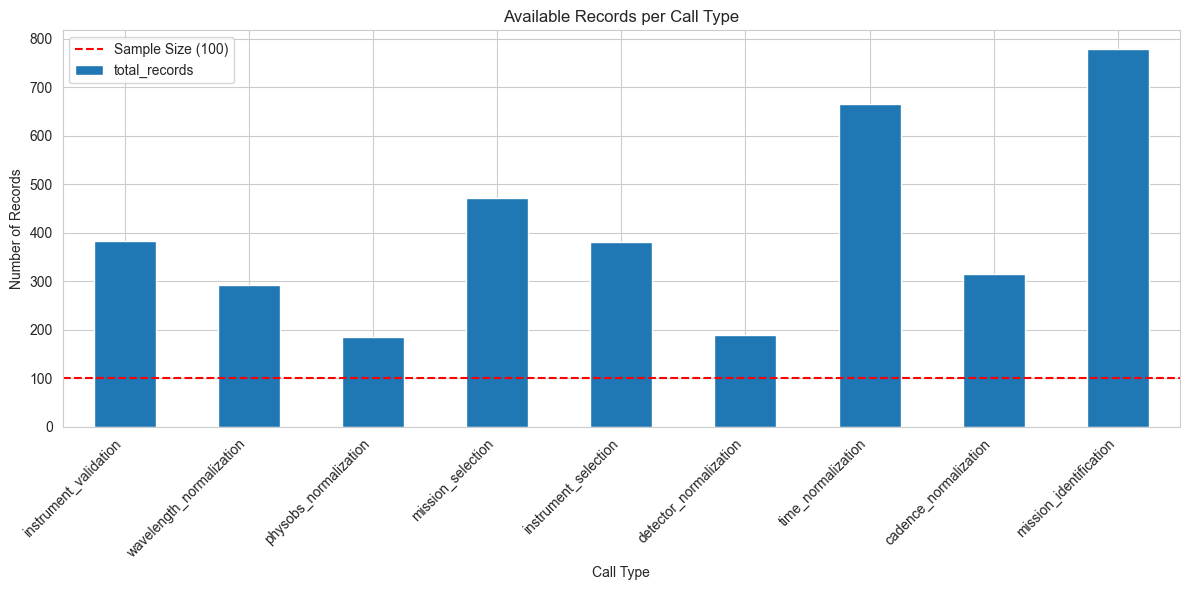

In [5]:
# Visualize record counts
fig, ax = plt.subplots(figsize=(12, 6))
df_summary.plot(x='call_type', y='total_records', kind='bar', ax=ax, legend=False)
ax.axhline(y=SAMPLE_SIZE, color='r', linestyle='--', label=f'Sample Size ({SAMPLE_SIZE})')
ax.set_title('Available Records per Call Type')
ax.set_xlabel('Call Type')
ax.set_ylabel('Number of Records')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Sample N records per call type
def sample_records(records, n, seed=None):
    """Sample n records randomly."""
    if len(records) <= n:
        return records
    
    if seed is not None:
        random.seed(seed)
    
    return random.sample(records, n)

# Sample and save to separate files (preserve originals!)
sampled_data = {}
for call_type, records in all_data.items():
    sampled = sample_records(records, SAMPLE_SIZE, RANDOM_SEED)
    sampled_data[call_type] = sampled
    
    # Save sampled data to separate file with sample size and seed in filename
    # This preserves the full export and allows re-sampling without re-downloading
    output_file = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}_sampled_{SAMPLE_SIZE}_seed{RANDOM_SEED}.jsonl"
    with open(output_file, 'w') as f:
        for record in sampled:
            f.write(json.dumps(record) + '\n')
    
    print(f"{call_type}: Sampled {len(sampled)} from {len(records)} records → {output_file.name}")

print(f"\n✅ Sampled {SAMPLE_SIZE} records per call type (seed={RANDOM_SEED})")
print(f"✅ Full exports preserved in: {INPUT_DIR}")
print(f"Total sampled records: {sum(len(s) for s in sampled_data.values())}")

instrument_validation: Sampled 100 from 382 records → instrument_validation_test_set_2025_11_26_sampled_100_seed42.jsonl
wavelength_normalization: Sampled 100 from 293 records → wavelength_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
physobs_normalization: Sampled 100 from 186 records → physobs_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
mission_selection: Sampled 100 from 472 records → mission_selection_test_set_2025_11_26_sampled_100_seed42.jsonl
instrument_selection: Sampled 100 from 381 records → instrument_selection_test_set_2025_11_26_sampled_100_seed42.jsonl
detector_normalization: Sampled 100 from 190 records → detector_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
time_normalization: Sampled 100 from 666 records → time_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
cadence_normalization: Sampled 100 from 314 records → cadence_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
mission_identification: Sampled 100 from

## 4. Run Self-Consistency Experiments

Execute 5 runs for each call type at temperature=1.0.

In [7]:
# Check which experiments have already been run (per model)
def check_experiment_status():
    """Check which experiments have been completed for each model."""
    status = {}
    for model in MODELS:
        slug = model_slug(model)
        status[model] = {}
        
        for call_type in CALL_TYPES:
            runs_found = []
            for run in range(1, NUM_RUNS + 1):
                # New structure: results/{test_set}/{model_slug}/{call_type}/run{N}/
                exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
                if exp_dir.exists():
                    # Check if results file exists
                    jsonl_files = list(exp_dir.glob('*.jsonl'))
                    if jsonl_files:
                        runs_found.append(run)
            
            status[model][call_type] = {
                'completed_runs': len(runs_found),
                'runs': runs_found,
                'complete': len(runs_found) >= NUM_RUNS
            }
    return status

exp_status = check_experiment_status()

# Create status matrix
print("\nExperiment Status by Model:")
print("="*80)

for model in MODELS:
    slug = model_slug(model)
    print(f"\n{model} ({slug}):")
    
    model_complete = []
    model_incomplete = []
    
    for call_type in CALL_TYPES:
        s = exp_status[model][call_type]
        if s['complete']:
            model_complete.append(call_type)
        else:
            model_incomplete.append((call_type, s['completed_runs']))
    
    if model_incomplete:
        print(f"  ⏳ Incomplete ({len(model_incomplete)}):")
        for ct, runs in model_incomplete:
            print(f"     - {ct}: {runs}/{NUM_RUNS} runs")
    
    if model_complete:
        print(f"  ✅ Complete ({len(model_complete)}): {', '.join(model_complete[:3])}{'...' if len(model_complete) > 3 else ''}")

# Find all incomplete experiments
incomplete = []
for model in MODELS:
    for call_type in CALL_TYPES:
        if not exp_status[model][call_type]['complete']:
            incomplete.append((model, call_type))

print(f"\n{'='*80}")
if incomplete:
    print(f"⚠️  {len(incomplete)} model/call-type combinations need experiments run")
else:
    print(f"✅ All experiments complete for all {len(MODELS)} models!")


Experiment Status by Model:

openai/gpt-5 (openai_gpt-5):
  ⏳ Incomplete (1):
     - time_normalization: 0/5 runs
  ✅ Complete (8): instrument_validation, wavelength_normalization, physobs_normalization...

bedrock/openai.gpt-oss-120b-1:0 (bedrock_openai_gpt-oss-120b-1_0):
  ✅ Complete (9): instrument_validation, wavelength_normalization, physobs_normalization...

⚠️  1 model/call-type combinations need experiments run


### AWS Credentials Check

Before running experiments, ensure AWS credentials are fresh (Bedrock requires valid SSO session).

In [8]:
import sys
sys.path.insert(0, '/Users/abuonomo/code/nasa/paper-data-linking')

# from paper_data_linking.config.settings import get_settings

# settings = get_settings()

# Try a minimal Bedrock API call
try:
    from litellm import completion

    print("🔍 Testing Bedrock credentials...")

    response = completion(
        model="bedrock/openai.gpt-oss-120b-1:0",
        messages=[{"role": "user", "content": "hi"}],
        max_tokens=100,
        temperature=1.0,
    )

    if response and response.choices:
        print("✅ Credentials working! API call succeeded.")
        print(f"   Response: {response.choices[0].message.content}")
    else:
        print("❌ API call returned empty response - credentials likely expired")

except Exception as e:
    error_msg = str(e).lower()
    if 'credentials' in error_msg or 'expired' in error_msg or 'unauthorized' in error_msg:
        print("❌ AWS credentials expired or invalid!")
        print(f"   Error: {e}")
        print("\n   Run: aws sso login --profile bedrock")
    else:
        print(f"❌ API error: {e}")


🔍 Testing Bedrock credentials...
✅ Credentials working! API call succeeded.
   Response: Hello! 👋 How can I help you today?


In [9]:
response

ModelResponse(id='chatcmpl-1c59610c-39e8-46d8-b5e1-fcab37f63cdc', created=1768485743, model='openai.gpt-oss-120b-1:0', object='chat.completion', system_fingerprint=None, choices=[Choices(finish_reason='stop', index=0, message=Message(content='Hello! 👋 How can I help you today?', role='assistant', tool_calls=None, function_call=None, reasoning_content='The user says "hi". We need to respond. Probably greet and ask how can help. Use friendly tone.', thinking_blocks=[{'type': 'thinking', 'thinking': 'The user says "hi". We need to respond. Probably greet and ask how can help. Use friendly tone.'}], provider_specific_fields={'reasoningContentBlocks': [{'reasoningText': {'text': 'The user says "hi". We need to respond. Probably greet and ask how can help. Use friendly tone.'}}]}))], usage=Usage(completion_tokens=44, prompt_tokens=70, total_tokens=114, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetailsWrapper(audio_tokens=None, cached_tokens=0, text_tokens=None, image_

In [ ]:
# Run experiments using Python runner (replaces shell script)
from experiments.compare_models.self_consistency.run_experiments import (
    run_self_consistency_experiments,
    run_all_self_consistency_experiments,
)

if incomplete:
    print(f"Running self-consistency experiments...")
    print(f"Incomplete experiments: {len(incomplete)}")
    
    # Group by model for efficiency
    models_to_run = list(set(model for model, ct in incomplete))
    
    for model in models_to_run:
        # Find call types needing runs for this model
        call_types_for_model = [ct for m, ct in incomplete if m == model]
        
        print(f"\n{'#'*60}")
        print(f"# MODEL: {model}")
        print(f"# Call types to run: {len(call_types_for_model)}")
        print(f"{'#'*60}\n")
        
        # Run experiments for this model
        all_results = run_all_self_consistency_experiments(
            call_types=call_types_for_model,
            test_set=TEST_SET_TAG,
            call_type_configs=CALL_TYPE_CONFIG,
            num_runs=NUM_RUNS,
            model=model,
            max_cases=SAMPLE_SIZE,
            sample_size=SAMPLE_SIZE,
            random_seed=RANDOM_SEED,
        )
    
    print(f"\n✅ All experiments complete!")
else:
    print("✅ All experiments already completed for all models. Skipping.")

## 4b. Batch API Workflow (Alternative)

For large-scale experiments, use the Batch API for:
- **50% cost savings** - Batch pricing is half of standard API
- **No laptop required** - Submit and retrieve results async
- **Higher throughput** - Process thousands of requests efficiently

The batch workflow has 4 steps:
1. **Prepare** - Generate batch JSONL from test cases
2. **Submit** - Upload and start batch job
3. **Monitor** - Check status periodically  
4. **Retrieve** - Download results when complete

In [10]:
# Batch API imports and setup
from experiments.compare_models.self_consistency.batch_runner import (
    prepare_batch_file,
    submit_batch,
    check_batch_status,
    retrieve_batch_results,
    list_pending_batches,
    estimate_batch_cost,
)

# Select which models/call_types to run via batch (usually the incomplete ones from above)
BATCH_MODELS = [m for m in MODELS if any(
    not exp_status[m][ct]['complete'] for ct in CALL_TYPES
)]
BATCH_CALL_TYPES = CALL_TYPES  # or subset

print(f"Models needing batch runs: {BATCH_MODELS}")
print(f"Call types to batch: {len(BATCH_CALL_TYPES)}")

/Users/abuonomo/code/nasa/paper-data-linking/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Models needing batch runs: ['openai/gpt-5']
Call types to batch: 9


In [11]:
# Step 1: Prepare batch files for each model/call_type combination
# This generates the JSONL files needed for batch API submission

batch_files = {}

for model in BATCH_MODELS:
    for call_type in BATCH_CALL_TYPES:
        # Skip if already complete
        if exp_status[model][call_type]['complete']:
            print(f"✅ {model}/{call_type}: Already complete, skipping")
            continue
        
        try:
            batch_file = prepare_batch_file(
                call_type=call_type,
                test_set=TEST_SET_TAG,
                call_type_config=CALL_TYPE_CONFIG[call_type],
                model=model,
                num_runs=NUM_RUNS,
                sample_size=SAMPLE_SIZE,
                random_seed=RANDOM_SEED,
            )
            batch_files[(model, call_type)] = batch_file
            
            # Estimate cost
            cost = estimate_batch_cost(batch_file, model)
            print(f"  Est. cost: ${cost['estimated_cost_usd']:.2f} ({cost['total_requests']} requests)")
            
        except Exception as e:
            print(f"❌ {model}/{call_type}: {e}")

print(f"\n{'='*60}")
print(f"Prepared {len(batch_files)} batch files")
print(f"Total estimated cost: ${sum(estimate_batch_cost(f, m)['estimated_cost_usd'] for (m, _), f in batch_files.items()):.2f}")

✅ openai/gpt-5/instrument_validation: Already complete, skipping
✅ openai/gpt-5/wavelength_normalization: Already complete, skipping
✅ openai/gpt-5/physobs_normalization: Already complete, skipping
✅ openai/gpt-5/mission_selection: Already complete, skipping
✅ openai/gpt-5/instrument_selection: Already complete, skipping
✅ openai/gpt-5/detector_normalization: Already complete, skipping
  Using response_format: NormalizedTimeRange
Prepared batch file: /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/batches/test_set_2025_11_26/time_normalization_openai_gpt-5_20260115_090232.jsonl
  Cases: 100
  Runs per case: 5
  Total requests: 500
  Est. cost: $0.53 (500 requests)
✅ openai/gpt-5/cadence_normalization: Already complete, skipping
✅ openai/gpt-5/mission_identification: Already complete, skipping

Prepared 1 batch files
Total estimated cost: $0.53


In [12]:
# Step 2: Submit batches to API
# ⚠️ Only run this cell when ready to submit! Batches incur costs.

import asyncio

async def submit_all_batches():
    """Submit all prepared batch files."""
    batch_metadata = {}
    
    for (model, call_type), batch_file in batch_files.items():
        print(f"\nSubmitting {model}/{call_type}...")
        try:
            meta = await submit_batch(batch_file, model)
            batch_metadata[(model, call_type)] = meta
            print(f"  ✅ Batch ID: {meta['batch_id']}")
        except Exception as e:
            print(f"  ❌ Error: {e}")
    
    return batch_metadata

# Uncomment to submit:
# batch_metadata = asyncio.get_event_loop().run_until_complete(submit_all_batches())
# OR in Jupyter:
batch_metadata = await submit_all_batches()

# print("⚠️ Batch submission commented out - uncomment when ready")
print(f"Will submit {len(batch_files)} batches")


Submitting openai/gpt-5/time_normalization...
Submitting batch to openai...


2026-01-15 09:02:40 - httpx - INFO: HTTP Request: POST https://api.openai.com/v1/files "HTTP/1.1 200 OK"


  Uploaded file: file-6UL1hBFckiYBN9DiDokrET


2026-01-15 09:02:41 - httpx - INFO: HTTP Request: POST https://api.openai.com/v1/batches "HTTP/1.1 200 OK"


  Created batch: batch_6968f38064e081908910bd736eaaf543
  Metadata saved: /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/batches/test_set_2025_11_26/time_normalization_openai_gpt-5_20260115_090232.meta.json
  ✅ Batch ID: batch_6968f38064e081908910bd736eaaf543
Will submit 1 batches


In [ ]:
# Step 3: Monitor batch status
# Run this cell to check progress from OpenAI's API

# Reload batch_runner to pick up any code changes without kernel restart
import importlib
from experiments.compare_models.self_consistency import batch_runner
importlib.reload(batch_runner)
from experiments.compare_models.self_consistency.batch_runner import check_batch_status, list_pending_batches

async def check_all_batches():
    """Check status of all submitted batches from OpenAI API."""
    pending_batches = list_pending_batches(TEST_SET_TAG)
    
    if not pending_batches:
        print("No pending batches found.")
        return pd.DataFrame()
    
    status_data = []
    for meta in pending_batches:
        try:
            status = await check_batch_status(meta['batch_id'], meta['provider'])
            
            # Extract call type from filename
            filename = Path(meta['batch_file']).stem
            call_type = filename.split('_openai_')[0] if '_openai_' in filename else filename
            
            completed = status['completed']
            total = status['total']
            pct = (completed / total * 100) if total else 0
            
            status_data.append({
                'Call Type': call_type,
                'Status': status['status'],
                'Progress': f"{completed}/{total}",
                '%': f"{pct:.0f}%",
                'Batch ID': meta['batch_id'][:20] + '...',
            })
        except Exception as e:
            status_data.append({
                'Call Type': Path(meta['batch_file']).stem[:30],
                'Status': 'ERROR',
                'Progress': str(e)[:30],
                '%': '-',
                'Batch ID': meta.get('batch_id', 'N/A')[:20],
            })
    
    return pd.DataFrame(status_data)

# Check batch status from OpenAI
df_status = await check_all_batches()

if not df_status.empty:
    # Sort by completion percentage
    df_status['_pct'] = df_status['%'].str.replace('%', '').replace('-', '0').astype(float)
    df_status = df_status.sort_values('_pct', ascending=False).drop('_pct', axis=1)
    
    print("\n" + "="*80)
    print("BATCH STATUS (from OpenAI API)")
    print("="*80)
    print(df_status.to_string(index=False))
    
    # Summary
    completed = (df_status['Status'] == 'completed').sum()
    in_progress = (df_status['Status'] == 'in_progress').sum()
    print(f"\n✅ Completed: {completed}  |  ⏳ In Progress: {in_progress}  |  Total: {len(df_status)}")

2026-01-15 10:10:54 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca5d5a608190aa9d919b372e8af4 "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca646fb08190b85bea008dcf9dff "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-C1WqkBKT9BMuF1LuTgSj4H/content "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca6a23b081908113e5146de07327 "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-BK2ftjfs55dHd5M3XSz7eg/content "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca5b9fe08190859d7bf50ac7cfaf "HTTP/1.1 200 OK"
2026-01-15 10:10:55 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-HmeLpB9xtoasT75xyxrQxa/content "HTTP/1.1 200 OK"



BATCH STATUS (from OpenAI API)
               Call Type    Status Progress    %                Batch ID
    instrument_selection completed  500/500 100% batch_6967ca5d5a6081...
   cadence_normalization completed  500/500 100% batch_6967ca646fb081...
  mission_identification completed  500/500 100% batch_6967ca6a23b081...
       mission_selection completed  500/500 100% batch_6967ca5b9fe081...
      time_normalization completed  500/500 100% batch_6968f38064e081...
   instrument_validation completed  500/500 100% batch_6967ca55acf481...
wavelength_normalization completed  500/500 100% batch_6967ca57aa2481...
   physobs_normalization completed  500/500 100% batch_6967ca59d50081...
  detector_normalization completed  500/500 100% batch_6967ca5fd7b081...

✅ Completed: 9  |  ⏳ In Progress: 0  |  Total: 9


2026-01-15 10:10:56 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-QmRZqYsZB2HwFAv8MCa6wD/content "HTTP/1.1 200 OK"
2026-01-15 10:10:57 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-WMS7r6LHG6JK8fwFDSnGTR/content "HTTP/1.1 200 OK"


In [ ]:
# Step 4: Retrieve completed batch results
# Run this after batches show "completed" status

async def retrieve_all_results():
    """Retrieve results from all completed batches."""
    pending_batches = list_pending_batches(TEST_SET_TAG)
    
    results_summary = []
    for meta in pending_batches:
        # Check if completed
        status = await check_batch_status(meta['batch_id'], meta['provider'])
        
        if status['status'] != 'completed':
            print(f"⏳ {Path(meta['batch_file']).name}: {status['status']} - skipping")
            continue
        
        print(f"\n📥 Retrieving {Path(meta['batch_file']).name}...")
        try:
            results = await retrieve_batch_results(
                batch_id=meta['batch_id'],
                provider=meta['provider'],
                model=meta['model'],
                test_set=TEST_SET_TAG,
            )
            results_summary.append({
                'batch_file': Path(meta['batch_file']).name,
                'total_results': results['total_results'],
                'files': len(results['files']),
            })
            print(f"  ✅ Retrieved {results['total_results']} results to {len(results['files'])} files")
        except Exception as e:
            print(f"  ❌ Error: {e}")
    
    return results_summary

# Uncomment to retrieve:
results = await retrieve_all_results()

# print("⚠️ Retrieval commented out - uncomment when batches are complete")
print("Results will be written to: results/{test_set}/{model_slug}/{call_type}/run{N}/")

2026-01-15 10:11:01 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca5d5a608190aa9d919b372e8af4 "HTTP/1.1 200 OK"
2026-01-15 10:11:01 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca5d5a608190aa9d919b372e8af4 "HTTP/1.1 200 OK"



📥 Retrieving instrument_selection_openai_gpt-5_20260114_115402.jsonl...
Retrieving results from file-C1WqkBKT9BMuF1LuTgSj4H...


2026-01-15 10:11:01 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-C1WqkBKT9BMuF1LuTgSj4H/content "HTTP/1.1 200 OK"
2026-01-15 10:11:01 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-C1WqkBKT9BMuF1LuTgSj4H/content "HTTP/1.1 200 OK"
2026-01-15 10:11:01 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-C1WqkBKT9BMuF1LuTgSj4H/content "HTTP/1.1 200 OK"
2026-01-15 10:11:02 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca646fb08190b85bea008dcf9dff "HTTP/1.1 200 OK"


  instrument_selection/run1: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/instrument_selection/run1/openai_gpt-5_batch_20260115_101101.jsonl
  instrument_selection/run2: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/instrument_selection/run2/openai_gpt-5_batch_20260115_101101.jsonl
  instrument_selection/run3: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/instrument_selection/run3/openai_gpt-5_batch_20260115_101101.jsonl
  instrument_selection/run4: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/instrument_selection/run4/openai_gpt-5_batch_20260115_101101.jsonl
  instrument_selection/run5: 100 res

2026-01-15 10:11:02 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca646fb08190b85bea008dcf9dff "HTTP/1.1 200 OK"
2026-01-15 10:11:02 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-BK2ftjfs55dHd5M3XSz7eg/content "HTTP/1.1 200 OK"


...


📥 Retrieving detector_normalization_openai_gpt-5_20260114_115402.jsonl...


2026-01-15 10:11:08 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/batches/batch_6967ca5fd7b08190ba33712096030e3b "HTTP/1.1 200 OK"
2026-01-15 10:11:09 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-WMS7r6LHG6JK8fwFDSnGTR/content "HTTP/1.1 200 OK"


Retrieving results from file-WMS7r6LHG6JK8fwFDSnGTR...


2026-01-15 10:11:09 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-WMS7r6LHG6JK8fwFDSnGTR/content "HTTP/1.1 200 OK"
2026-01-15 10:11:09 - httpx - INFO: HTTP Request: GET https://api.openai.com/v1/files/file-WMS7r6LHG6JK8fwFDSnGTR/content "HTTP/1.1 200 OK"


  detector_normalization/run1: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/detector_normalization/run1/openai_gpt-5_batch_20260115_101109.jsonl
  detector_normalization/run2: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/detector_normalization/run2/openai_gpt-5_batch_20260115_101109.jsonl
  detector_normalization/run3: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/detector_normalization/run3/openai_gpt-5_batch_20260115_101109.jsonl
  detector_normalization/run4: 100 results -> /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/self_consistency/results/test_set_2025_11_26/openai_gpt-5/detector_normalization/run4/openai_gpt-5_batch_20260115_101109.jsonl
  detector_normaliza

## 5. Results Analysis

Calculate Fleiss' kappa and consistency metrics.

In [ ]:
# Load experiment results with correct handler parsing (per model)
import importlib

# Map call types to their correct handler classes
HANDLER_MAP = {
    'detector_normalization': 'DetectorNormalizationFreeTextV2Handler',
    'cadence_normalization': 'CadenceNormalizationFreeTextHandler',
    'physobs_normalization': 'PhysObsNormalizationFreeTextV2Handler',
    'wavelength_normalization': 'WavelengthNormalizationSimpleHandler',
    'time_normalization': 'TimeNormalizationHandler',
    'mission_identification': 'MissionIdentificationHandler',
    'mission_selection': 'MissionSelectionHandler',
    'instrument_selection': 'InstrumentSelectionHandler',
    'instrument_validation': 'InstrumentValidationHandler',
}

# Response keys for each call type
# NOTE: time_normalization uses tuple of fields since it returns a single complex object
RESPONSE_KEYS = {
    'detector_normalization': 'detector',
    'cadence_normalization': 'cadences',
    'physobs_normalization': 'physical_observable',
    'wavelength_normalization': 'wavelengths',
    'time_normalization': ('start_datetime', 'end_datetime'),  # FIXED: tuple of fields
    'mission_identification': 'mission_indices',
    'mission_selection': 'mission_indices',
    'instrument_selection': 'instrument_indices',
    'instrument_validation': 'validation_result',
}

# Task type classification
TASK_TYPES = {
    'instrument_validation': 'binary',
    'detector_normalization': 'single',
    'physobs_normalization': 'single',
    'time_normalization': 'single',
    'wavelength_normalization': 'set',
    'cadence_normalization': 'set',
    'mission_selection': 'set',
    'instrument_selection': 'set',
    'mission_identification': 'set',
}

def load_handler(call_type):
    """Load the correct handler class for a call type."""
    handler_class_name = HANDLER_MAP[call_type]
    
    # Import from handlers package
    handlers_module = importlib.import_module('experiments.compare_models.handlers')
    handler_class = getattr(handlers_module, handler_class_name)
    
    return handler_class()


def extract_response_value(parsed, call_type):
    """Extract comparable value from parsed response."""
    if parsed is None:
        return 'PARSE_ERROR'
    
    response_key = RESPONSE_KEYS.get(call_type)
    
    # Handle time_normalization specially (tuple of fields)
    if isinstance(response_key, tuple):
        values = tuple(parsed.get(field) for field in response_key)
        return str(values)
    
    # Standard extraction
    if isinstance(parsed, dict):
        response_val = parsed.get(response_key)
    else:
        response_val = parsed
    
    # Normalize for comparison
    if isinstance(response_val, list):
        response_val = tuple(sorted(str(v) for v in response_val))
    
    return str(response_val)


def load_experiment_results(model, call_type):
    """Load all runs for a call type and model and calculate consistency."""
    all_cases = defaultdict(lambda: {'responses': []})
    
    handler = load_handler(call_type)
    slug = model_slug(model)
    
    for run in range(1, NUM_RUNS + 1):
        exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if not jsonl_files:
            continue
        
        with open(jsonl_files[0]) as f:
            for line in f:
                data = json.loads(line)
                case_id = data.get('original_id', data.get('case_index'))
                output_content = data.get('output_content', '')
                
                try:
                    parsed = handler.parse_response(output_content)
                except Exception as e:
                    parsed = None
                
                response = extract_response_value(parsed, call_type)
                all_cases[case_id]['responses'].append(response)
    
    # Calculate consistency
    perfect = 0
    high = 0
    moderate = 0
    low = 0
    no_consistency = 0
    disagreements = []
    
    for case_id, info in all_cases.items():
        responses = info['responses']
        if not responses:
            continue
            
        unique = set(responses)
        max_agreement = max(Counter(responses).values())
        
        if max_agreement == NUM_RUNS:
            perfect += 1
        elif max_agreement == NUM_RUNS - 1:
            high += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        elif max_agreement == NUM_RUNS - 2:
            moderate += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        elif max_agreement == 2:
            low += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        else:
            no_consistency += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
    
    total = len(all_cases)
    
    return {
        'total': total,
        'perfect': perfect,
        'high': high,
        'moderate': moderate,
        'low': low,
        'no_consistency': no_consistency,
        'disagreements': disagreements
    }


# Analyze all call types for all models
results = {}
for model in MODELS:
    results[model] = {}
    print(f"\nAnalyzing {model}...")
    for call_type in CALL_TYPES:
        results[model][call_type] = load_experiment_results(model, call_type)
        
        r = results[model][call_type]
        task_type = TASK_TYPES[call_type]
        marker = {'binary': '○', 'single': '◐', 'set': '●'}[task_type]
        
        if r['total'] > 0:
            perfect_pct = r['perfect'] / r['total'] * 100
            print(f"  {call_type} {marker}: {perfect_pct:.0f}% perfect ({r['perfect']}/{r['total']})")

print("\n" + "="*60)
print("Task types: ○=binary, ◐=single value, ●=set (list)")
print("For Jaccard-based analysis, see model_comparison_analysis.ipynb")
print("="*60)
print("\n✅ Loaded results for all models")

In [ ]:
# Create summary table (multi-model)
summary_results = []
for call_type in CALL_TYPES:
    row = {'Call Type': call_type}
    
    for model in MODELS:
        result = results[model][call_type]
        total = result['total']
        
        if total == 0:
            row[f'{model_slug(model)[:15]} Perfect'] = 'N/A'
        else:
            perfect_pct = result['perfect'] / total * 100
            row[f'{model_slug(model)[:15]} Perfect'] = f"{perfect_pct:.0f}%"
    
    summary_results.append(row)

df_results = pd.DataFrame(summary_results)

print("\n" + "="*100)
print("SELF-CONSISTENCY RESULTS SUMMARY (Perfect Agreement Rate)")
print("="*100)
print(df_results.to_string(index=False))

# Also create detailed view for first model
print("\n" + "="*100)
print(f"DETAILED VIEW: {MODELS[0]}")
print("="*100)

detailed_results = []
for call_type in CALL_TYPES:
    result = results[MODELS[0]][call_type]
    total = result['total']
    if total == 0:
        continue
    
    detailed_results.append({
        'Call Type': call_type,
        'Total': total,
        f'Perfect ({NUM_RUNS}/{NUM_RUNS})': f"{result['perfect']} ({result['perfect']/total*100:.1f}%)",
        f'High ({NUM_RUNS-1}/{NUM_RUNS})': f"{result['high']} ({result['high']/total*100:.1f}%)",
        f'Moderate ({NUM_RUNS-2}/{NUM_RUNS})': f"{result['moderate']} ({result['moderate']/total*100:.1f}%)",
        'Disagreements': len(result['disagreements'])
    })

df_detailed = pd.DataFrame(detailed_results)
print(df_detailed.to_string(index=False))

In [ ]:
# Visualize consistency rates (multi-model comparison)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Perfect consistency rates by model (grouped bar)
x = range(len(CALL_TYPES))
width = 0.8 / len(MODELS)

for i, model in enumerate(MODELS):
    rates = []
    for ct in CALL_TYPES:
        r = results[model][ct]
        if r['total'] > 0:
            rates.append(r['perfect'] / r['total'] * 100)
        else:
            rates.append(0)
    
    ax1.bar([xi + i * width for xi in x], rates, width, 
            label=model_slug(model)[:20], alpha=0.8)

ax1.set_xlabel('Call Type')
ax1.set_ylabel('Perfect Agreement Rate (%)')
ax1.set_title('Self-Consistency: Perfect Agreement by Model')
ax1.set_xticks([xi + width * (len(MODELS) - 1) / 2 for xi in x])
ax1.set_xticklabels(CALL_TYPES, rotation=45, ha='right')
ax1.legend(title='Model')
ax1.axhline(y=90, color='green', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 105)

# Plot 2: Heatmap of perfect agreement rates
heatmap_data = []
for model in MODELS:
    row = []
    for ct in CALL_TYPES:
        r = results[model][ct]
        if r['total'] > 0:
            row.append(r['perfect'] / r['total'] * 100)
        else:
            row.append(0)
    heatmap_data.append(row)

df_heatmap = pd.DataFrame(heatmap_data, 
                          index=[model_slug(m)[:20] for m in MODELS],
                          columns=CALL_TYPES)

sns.heatmap(df_heatmap, annot=True, fmt='.0f', cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax2, cbar_kws={'label': 'Perfect Agreement %'})
ax2.set_title('Self-Consistency Heatmap')
ax2.set_xlabel('Call Type')
ax2.set_ylabel('Model')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 6. Detailed Investigation

Examine specific disagreement cases.

In [ ]:
# Show disagreement examples for problematic call types (select model)
REVIEW_MODEL = MODELS[0]  # Change this to review different model

print(f"\nReviewing disagreements for: {REVIEW_MODEL}")
print("="*80)

problematic = [(ct, results[REVIEW_MODEL][ct]['perfect']/results[REVIEW_MODEL][ct]['total']*100) 
               for ct in CALL_TYPES if results[REVIEW_MODEL][ct]['total'] > 0 and 
               results[REVIEW_MODEL][ct]['perfect']/results[REVIEW_MODEL][ct]['total']*100 < 95]

if not problematic:
    print(f"✅ No call types with <95% perfect agreement for {REVIEW_MODEL}")
else:
    for call_type, perfect_rate in sorted(problematic, key=lambda x: x[1]):
        print("\n" + "="*80)
        print(f"{call_type.upper()} - {perfect_rate:.1f}% perfect agreement")
        print("="*80)
        
        disagreements = results[REVIEW_MODEL][call_type]['disagreements']
        print(f"Total disagreements: {len(disagreements)}\n")
        
        # Show top 5 most inconsistent cases
        sorted_disagreements = sorted(disagreements, 
                                      key=lambda x: len(x['responses']), 
                                      reverse=True)[:5]
        
        for i, case in enumerate(sorted_disagreements, 1):
            print(f"{i}. Case {str(case['case_id'])[:8]}...")
            print(f"   Unique responses: {len(case['responses'])}")
            for response, count in case['responses'].most_common():
                print(f"   - {count}x: {response[:100]}")
            print()

In [ ]:
# Inspect a specific disagreement case in detail
call_type_to_inspect = 'instrument_validation'  # Change this
model_to_inspect = MODELS[0]  # Change this
case_index = 0  # First disagreement case

if results[model_to_inspect][call_type_to_inspect]['disagreements']:
    case = results[model_to_inspect][call_type_to_inspect]['disagreements'][case_index]
    case_id = case['case_id']
    
    print(f"\n{'='*80}")
    print(f"DETAILED CASE INSPECTION: {call_type_to_inspect}")
    print(f"Model: {model_to_inspect}")
    print(f"Case ID: {case_id}")
    print(f"{'='*80}\n")
    
    # Load the actual data from all runs
    slug = model_slug(model_to_inspect)
    for run in range(1, NUM_RUNS + 1):
        # New structure: results/{test_set}/{model_slug}/{call_type}/run{N}/
        exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type_to_inspect / f"run{run}"
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if jsonl_files:
            with open(jsonl_files[0]) as f:
                for line in f:
                    data = json.loads(line)
                    if data.get('original_id') == case_id or data.get('case_index') == case_id:
                        print(f"Run {run}:")
                        print(f"  Output: {data.get('output_content', '')[:200]}")
                        print(f"  Parsed: {data.get('parsed_response')}")
                        print()
                        break
else:
    print(f"No disagreements found for {model_to_inspect} / {call_type_to_inspect}")

## 7. Generate Final Report

Create markdown report for technical documentation.

In [ ]:
# Generate comprehensive report
!cd ../.. && python scripts/generate_self_consistency_report.py

print("\n✅ Report generated: experiments/compare_models/test_set_2025_11_26_self_consistency_report.md")

## Summary

This notebook demonstrated:
1. ✅ Exporting LLM calls from production with render context
2. ✅ Random sampling to avoid temporal bias
3. ✅ Running self-consistency experiments for **multiple models**
4. ✅ Analyzing results with consistency metrics per model
5. ✅ Investigating disagreement patterns

**Key Insight:** Self-consistency is the **foundation** for model comparison.
- Run self-consistency for EACH model you want to compare
- Then use `model_comparison_analysis.ipynb` for cross-model analysis

**Results Directory Structure:**
```
results/{test_set}/{model_slug}/{call_type}/run{1-N}/
```

**Next Steps:**
- Run `model_comparison_analysis.ipynb` to compare models
- Investigate low-consistency call types
- Include results in technical report

## 8. Export Publication Figures

Save figures for paper/report with consistent styling.

In [ ]:
# Figure export configuration
FIGURE_DIR = Path('../../exports/figures/self_consistency')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Common settings
FIGURE_DPI = 300
FIGURE_STYLE = 'seaborn-v0_8-whitegrid'

def save_figure(fig, name, dpi=FIGURE_DPI):
    """Save figure in both PNG and PDF formats."""
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    
    fig.savefig(png_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    
    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path

# Prepare data for figures
df_viz = pd.DataFrame([
    {
        'task': ct.replace('_', ' ').title(),
        'perfect': results[ct]['perfect'],
        'high': results[ct]['high'],
        'moderate': results[ct]['moderate'],
        'low_none': results[ct]['low'] + results[ct]['no_consistency'],
        'total': results[ct]['total']
    }
    for ct in CALL_TYPES if results[ct]['total'] > 0
])
df_viz['perfect_pct'] = df_viz['perfect'] / df_viz['total'] * 100
df_viz = df_viz.sort_values('perfect_pct', ascending=True)

print(f"Figure output directory: {FIGURE_DIR.absolute()}")

In [ ]:
# Figure 1: Stacked horizontal bar chart - Self-consistency breakdown
plt.style.use(FIGURE_STYLE)

fig, ax = plt.subplots(figsize=(10, 6))

# Create stacked bars
tasks = df_viz['task'].values
y_pos = range(len(tasks))

# Calculate percentages
perfect_pct = df_viz['perfect'].values / df_viz['total'].values * 100
high_pct = df_viz['high'].values / df_viz['total'].values * 100
moderate_pct = df_viz['moderate'].values / df_viz['total'].values * 100
low_pct = df_viz['low_none'].values / df_viz['total'].values * 100

# Colors
colors = {
    'perfect': '#2ecc71',    # Green
    'high': '#82e0aa',       # Light green
    'moderate': '#f4d03f',   # Yellow
    'low': '#e74c3c'         # Red
}

# Plot stacked bars
bars1 = ax.barh(y_pos, perfect_pct, label='Perfect (5/5)', color=colors['perfect'])
bars2 = ax.barh(y_pos, high_pct, left=perfect_pct, label='High (4/5)', color=colors['high'])
bars3 = ax.barh(y_pos, moderate_pct, left=perfect_pct+high_pct, label='Moderate (3/5)', color=colors['moderate'])
bars4 = ax.barh(y_pos, low_pct, left=perfect_pct+high_pct+moderate_pct, label='Low/None', color=colors['low'])

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks)
ax.set_xlabel('Percentage of Test Cases', fontsize=11)
ax.set_title('Self-Consistency Analysis: Agreement Across 5 Runs (temp=1.0)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)

# Add percentage labels on bars
for i, (p, h, m, l) in enumerate(zip(perfect_pct, high_pct, moderate_pct, low_pct)):
    if p > 10:  # Only label if there's room
        ax.text(p/2, i, f'{p:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Legend
ax.legend(loc='lower right', fontsize=9)

# Add vertical line at 90%
ax.axvline(x=90, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(91, len(tasks)-0.5, '90%', fontsize=8, color='gray')

plt.tight_layout()
save_figure(fig, 'self_consistency_stacked_breakdown')
plt.show()

In [ ]:
# Figure 2: Simple bar chart - Perfect agreement rates only
fig, ax = plt.subplots(figsize=(10, 5))

# Color bars by tier
tier_colors = []
for pct in df_viz['perfect_pct'].values:
    if pct >= 93:
        tier_colors.append('#2ecc71')  # Green - excellent
    elif pct >= 80:
        tier_colors.append('#3498db')  # Blue - strong
    else:
        tier_colors.append('#e67e22')  # Orange - moderate

bars = ax.barh(df_viz['task'], df_viz['perfect_pct'], color=tier_colors)

# Add value labels
for bar, pct in zip(bars, df_viz['perfect_pct']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=10)

# Formatting
ax.set_xlabel('Perfect Agreement Rate (%)', fontsize=11)
ax.set_title('Self-Consistency: Perfect Agreement (5/5 runs) by Task', fontsize=12, fontweight='bold')
ax.set_xlim(0, 105)

# Add tier threshold lines
ax.axvline(x=93, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(x=80, color='blue', linestyle='--', alpha=0.4, linewidth=1)

# Custom legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Tier 1: Excellent (≥93%)'),
    Patch(facecolor='#3498db', label='Tier 2: Strong (80-92%)'),
    Patch(facecolor='#e67e22', label='Tier 3: Moderate (<80%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
save_figure(fig, 'self_consistency_perfect_agreement')
plt.show()

In [ ]:
# List all exported figures
print("Exported figures:")
for f in sorted(FIGURE_DIR.glob('*')):
    print(f"  {f.name}")

print(f"\nFull path: {FIGURE_DIR.absolute()}")
print("\nTo regenerate: Re-run cells 26-28 in this notebook")